In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
df=pd.read_excel("ABC Company.xlsx")
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2026-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2026-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2026-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2026-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2026-10-06 00:00:00,231,NaN,5000000.0


In [109]:
df.shape

(458, 9)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [111]:
df.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

# Preprocessing:

### Correct the data in the "height" column by replacing it with random numbers between 150 and 180. Ensure data consistency and integrity before proceeding with analysis.

In [112]:
df["Height"] = np.random.randint(150, 181, size=len(df))

In [113]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,158,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,178,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,151,231,NaN,5000000.0


# Analysis Tasks:

#### Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.

In [114]:
team_count=df["Team"].value_counts()
team_count

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
New York Knicks           16
Milwaukee Bucks           16
Brooklyn Nets             15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Denver Nuggets            15
Washington Wizards        15
Miami Heat                15
Charlotte Hornets         15
Atlanta Hawks             15
San Antonio Spurs         15
Houston Rockets           15
Boston Celtics            15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Sacramento Kings          15
Phoenix Suns              15
Los Angeles Lakers        15
Los Angeles Clippers      15
Golden State Warriors     15
Toronto Raptors           15
Philadelphia 76ers        15
Dallas Mavericks          15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

In [115]:
team_perc=df["Team"].value_counts(normalize=True)*100
team_perc

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275109
Orlando Magic  

#### Segregate employees based on their positions within the company.

In [116]:
position_count=df["Position"].value_counts()
position_count

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64

#### Identify the predominant age group among employees.

In [117]:
age_group = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 70])
age_count = age_group.value_counts().sort_index()
age_count

Age
(20, 30]    346
(30, 40]     91
(40, 50]      0
(50, 60]      0
(60, 70]      0
Name: count, dtype: int64

#### Discover which team and position have the highest salary expenditure.

In [118]:
team_salary = df.groupby("Team")["Salary"].sum()
team_salary.sort_values(ascending=False)

Team
Cleveland Cavaliers       106988689.0
Los Angeles Clippers       94854640.0
Oklahoma City Thunder      93765298.0
Golden State Warriors      88868997.0
Chicago Bulls              86783378.0
San Antonio Spurs          84442733.0
New Orleans Pelicans       82750774.0
Miami Heat                 82515673.0
Charlotte Hornets          78340920.0
Memphis Grizzlies          76550880.0
Washington Wizards         76328636.0
Houston Rockets            75283021.0
New York Knicks            73303898.0
Atlanta Hawks              72902950.0
Los Angeles Lakers         71770431.0
Sacramento Kings           71683666.0
Dallas Mavericks           71198732.0
Toronto Raptors            71117611.0
Milwaukee Bucks            69603517.0
Detroit Pistons            67168263.0
Indiana Pacers             66751826.0
Utah Jazz                  64007367.0
Phoenix Suns               63445135.0
Orlando Magic              60161470.0
Denver Nuggets             60121930.0
Minnesota Timberwolves     59709697.0
Boston 

In [119]:
position_salary = df.groupby("Position")["Salary"].sum()
position_salary.sort_values(ascending=False)

Position
C     466377332.0
PG    446848971.0
PF    442560850.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64

#### Investigate if there's any correlation between age and salary, and represent it visually.

In [120]:
correlation = df["Age"].corr(df["Salary"])
correlation

np.float64(0.21400941226570974)

#It shows weak positive correlation.

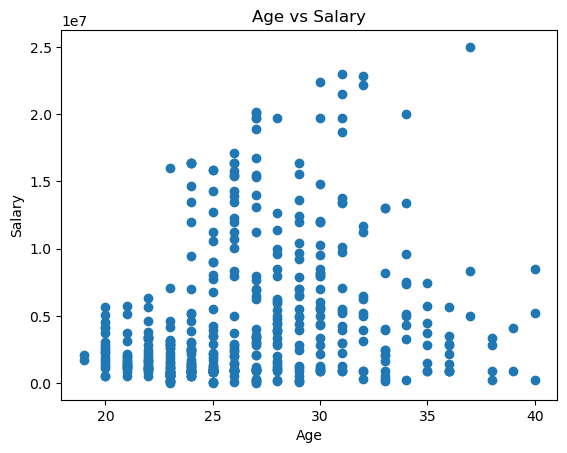

In [121]:
plt.scatter(df["Age"], df["Salary"])

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

# Graphical Representation:

#### For each of the five analysis tasks above, create appropriate visualizations to present your findings effectively.

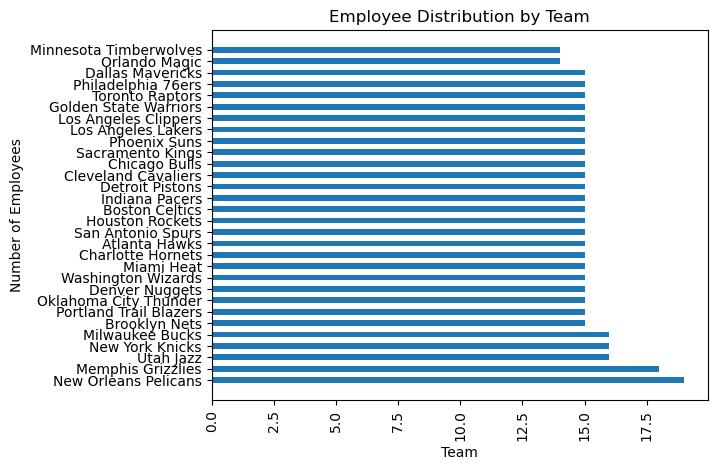

In [122]:
#Employee dist across each team
plt.barh(team_count.index, team_count.values,height=0.5)

plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.title("Employee Distribution by Team")
plt.xticks(rotation=90)
plt.show()

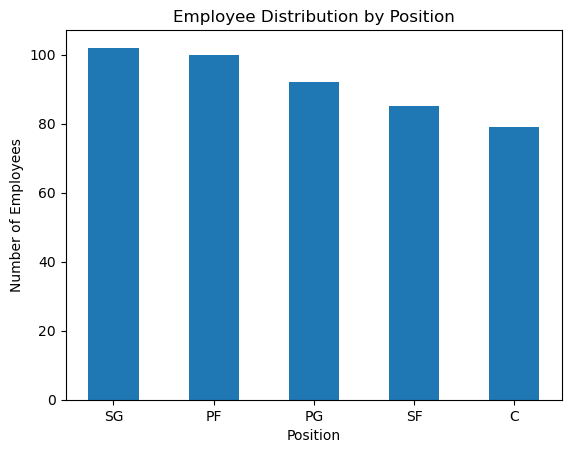

In [123]:
#employees based on position
plt.bar(position_count.index, position_count.values,width=0.5)
plt.title("Employee Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")
plt.show()

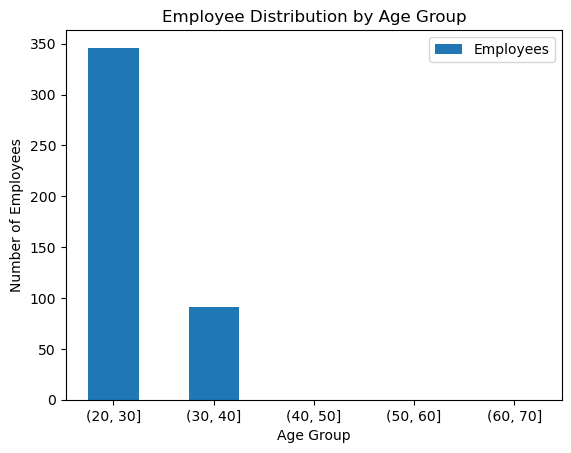

In [124]:
#Age group among employees.
age_group = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 70])

age_count = age_group.value_counts().sort_index()

plt.bar(age_count.index.astype(str), age_count.values, width=0.5, label="Employees")

plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.title("Employee Distribution by Age Group")
plt.legend()

plt.show()

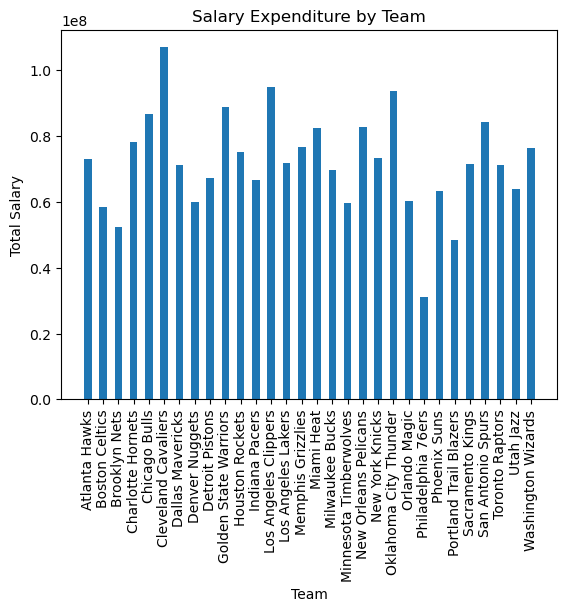

In [125]:
#Highest salary expenditure
#By Team
plt.bar(team_salary.index, team_salary.values,width=0.5)
plt.title("Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.xticks(rotation=90)
plt.show()

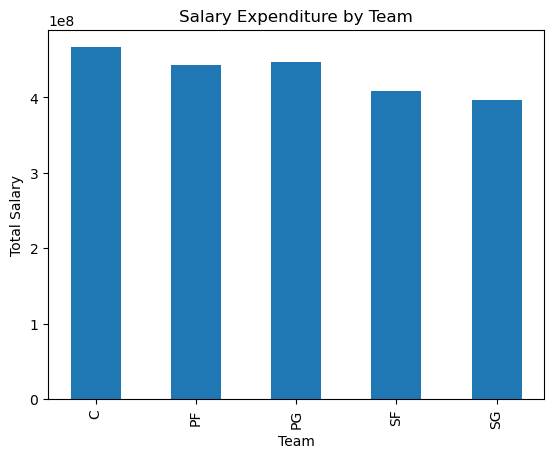

In [126]:
#By Position
plt.bar(position_salary.index, position_salary.values,width=0.5)
plt.title("Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.xticks(rotation=90)
plt.show()

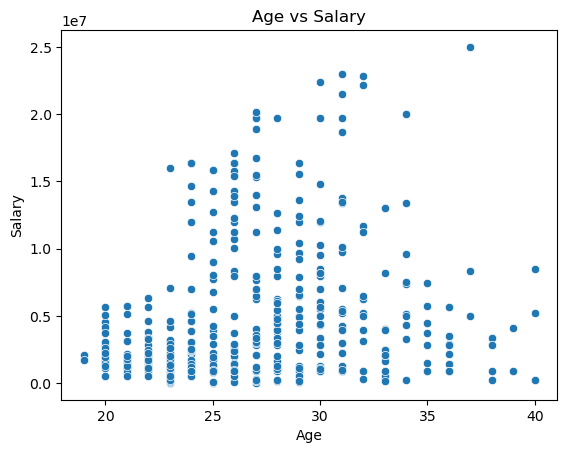

In [127]:
#correlation between age and salary
sns.scatterplot(x="Age", y="Salary", data=df)
plt.title("Age vs Salary")
plt.show()

### Data Story: Provide insights gained from the analysis
### The analysis shows several important trends and patterns in the dataset. The distribution of employees across teams is not equal, with some teams having a larger number of employees than others. The analysis of age groups also shows that employees are concentrated in certain age ranges. The analysis reveals important trends, patterns, and correlations within the dataset. The distribution of different categories shows which groups have higher or lower representation, while the numerical variables reveal noticeable relationships between them. These findings help identify common patterns in the data and understand how different variables are related to each other.